# Binary Source Resolution Limit Test

This notebook quantifies the spatial resolution limit of the DDPM deconvolution / super-resolution models on synthetic binary Gaussian sources.

It implements:

- configurable dataset/model loading
- DDPM inference for 200 LR images
- binary-source saddle dip ratio calculation
- 20 × 10 resolution phase diagrams over source separation `d` and flux ratio `F2/F1`
- DDPM boundary vs. raw LHAASO observation boundary
- representative 2D/1D visualization for a selected case


In [1]:
from pathlib import Path
import csv
import importlib
import json
import sys
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from scipy.signal import find_peaks
from tqdm.auto import tqdm

plt.rcParams["figure.dpi"] = 120


def find_repo_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "codes").exists() and (candidate / "data").exists():
            return candidate
    raise RuntimeError("Could not find repo root containing codes/ and data/.")


ADDR_ROOT = find_repo_root()
ADDR_CODE = ADDR_ROOT / "codes"
ADDR_MODELS = ADDR_CODE / "models"
for path in [ADDR_ROOT, ADDR_CODE, ADDR_MODELS]:
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.append(path_str)

from codes.config.config_DDPM import ModelConfig

print(f"ADDR_ROOT = {ADDR_ROOT}")
print(f"CUDA available = {torch.cuda.is_available()}")


ADDR_ROOT = /root/LHAI_novel
CUDA available = True


/root/miniconda3/envs/LHAI/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_DIR = ADDR_ROOT / "data" / "Evaluation"
MODEL_WEIGHT_DIR = ADDR_ROOT / "saves" / "MODEL" / "DDPM"
OUTPUT_DIR = ADDR_ROOT / "saves" / "EVAL" / "DDPM" / "PhysicalLimit"

MAP_KIND = "poisonon"
SIGMA_KIND = "1sgma"
IMAGE_SIZE = 64
DATA_RANGE = 2.0

DATA_NAME = f"PL{MAP_KIND}_{SIGMA_KIND}_200_{IMAGE_SIZE}_test.npy"
MODEL_WEIGHT_NAME = "Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.pth"

DIFFUSION_CONFIG_KEY = "DDPM_64"
DIFFUSION_MODULE_NAME = "DDPM"
DIFFUSION_CLASS_NAME = "DDPM"
UNET_CONFIG_KEY = "UNET"
UNET_MODULE_NAME = "UNET"
UNET_CLASS_NAME = "UNET"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
STRICT_LOAD = True
CLAMP_OUTPUT = False
OVERRIDE_IMG_SIZE_FROM_DATA = True
INFERENCE_BATCH_SIZE = 50
SAMPLING_SEED = 2026

N_FLUX_RATIOS = 10
N_SEPARATIONS = 20
FLUX_RATIOS = np.linspace(0.1, 1.0, N_FLUX_RATIOS)
SEPARATIONS_DEG = np.linspace(0.1, 1.0, N_SEPARATIONS)
DIP_THRESHOLD = 0.10
REPRESENTATIVE_INDEX = 95
REPRESENTATIVE_COUNT = 6
REPRESENTATIVE_SELECTION = "lr_unresolved_ddpm_resolved"
MANUAL_CASE_INDICES = []
FAILURE_CASE_COUNT = 4
PIXEL_SIZE_DEG = 6.4 / IMAGE_SIZE
SOURCE_CENTER_X_PIX = (IMAGE_SIZE - 1) / 2
SOURCE_CENTER_Y_PIX = IMAGE_SIZE // 2
PRIOR_PEAK_SEARCH_RADIUS_PIX = 2
SAVE_OUTPUTS = True


In [3]:
data_path = DATA_DIR / DATA_NAME
if not data_path.exists():
    raise FileNotFoundError(data_path)

weight_files = sorted(MODEL_WEIGHT_DIR.glob("*.pth")) if MODEL_WEIGHT_DIR.exists() else []
print("Available DDPM weights:")
for path in weight_files:
    print(" ", path.name)
if MODEL_WEIGHT_NAME is None:
    raise ValueError("Set MODEL_WEIGHT_NAME in the config cell to the matching DDPM weight.")
model_weight_path = MODEL_WEIGHT_DIR / MODEL_WEIGHT_NAME
if not model_weight_path.exists():
    raise FileNotFoundError(model_weight_path)

data = np.load(data_path, allow_pickle=True).astype(np.float32)
if data.shape != (200, 2, IMAGE_SIZE, IMAGE_SIZE):
    raise ValueError(f"Expected (200,2,{IMAGE_SIZE},{IMAGE_SIZE}), got {data.shape}")
gt_np = data[:, 0]
lr_np = data[:, 1]
print(f"Loaded {data_path.name}: {data.shape}")
print(f"GT range=({gt_np.min():.4g}, {gt_np.max():.4g}), LR range=({lr_np.min():.4g}, {lr_np.max():.4g})")


Available DDPM weights:
  Last_DDPM_EXP01_400epo_32bth_128size_SR4bkgon.pth
  Last_DDPM_EXP01_400epo_32bth_128size_SR4excess.pth
  Last_DDPM_EXP01_400epo_32bth_128size_SR4poisonon.pth
  Last_DDPM_EXP01_400epo_32bth_64size_SR4bkgon.pth
  Last_DDPM_EXP01_400epo_32bth_64size_SR4excess.pth
  Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.pth
Loaded PLpoisonon_1sgma_200_64_test.npy: (200, 2, 64, 64)
GT range=(122.1, 1.263e+06), LR range=(1225, 1.867e+05)


In [4]:
def minmax_normalize_batch(images, data_range=1.0):
    images = images.astype(np.float32, copy=False)
    flat = images.reshape(images.shape[0], -1)
    mins = flat.min(axis=1).reshape((-1, 1, 1))
    maxs = flat.max(axis=1).reshape((-1, 1, 1))
    norm01 = (images - mins) / np.maximum(maxs - mins, 1e-8)
    if abs(data_range - 1.0) < 1e-6:
        return norm01
    if abs(data_range - 2.0) < 1e-6:
        return 2.0 * norm01 - 1.0
    raise ValueError("DATA_RANGE must be 1.0 or 2.0")


def import_model_class(module_name, class_name):
    module = importlib.import_module(f"codes.models.{module_name}")
    return getattr(module, class_name)


lr_model_np = minmax_normalize_batch(lr_np, DATA_RANGE)
gt_model_np = minmax_normalize_batch(gt_np, DATA_RANGE)

model_cfg = ModelConfig()
model_params = model_cfg.model_params
params_diffusion = dict(model_params[DIFFUSION_CONFIG_KEY])
params_unet = dict(model_params[UNET_CONFIG_KEY])
if OVERRIDE_IMG_SIZE_FROM_DATA and params_diffusion.get("img_size") != IMAGE_SIZE:
    params_diffusion["img_size"] = IMAGE_SIZE
params_diffusion["device"] = torch.device(DEVICE)

device = torch.device(DEVICE)
DIFFUSION = import_model_class(DIFFUSION_MODULE_NAME, DIFFUSION_CLASS_NAME)
UNET = import_model_class(UNET_MODULE_NAME, UNET_CLASS_NAME)
diffusion = DIFFUSION(**params_diffusion)
unet = UNET(**params_unet).to(device)
if hasattr(unet, "build"):
    unet.build()
unet.to(device)
state = torch.load(model_weight_path, map_location=device)
if isinstance(state, dict) and "state_dict" in state:
    state = state["state_dict"]
unet.load_state_dict(state, strict=STRICT_LOAD)
unet.eval()
print(f"Loaded model: {DIFFUSION_CONFIG_KEY} + {UNET_CONFIG_KEY} on {device}")


Loaded model: DDPM_64 + UNET on cuda


In [5]:
def reduce_generated(generated, batch_size):
    if generated.dim() == 5:
        if generated.shape[0] == batch_size:
            generated = generated[:, -1]
        else:
            generated = generated[-1]
    if CLAMP_OUTPUT:
        generated = generated.clamp(-1.0, 1.0) if DATA_RANGE == 2.0 else generated.clamp(0.0, 1.0)
    return generated


@torch.no_grad()
def generate_ddpm_outputs(lr_batch_np):
    outputs = []
    for start in tqdm(range(0, len(lr_batch_np), INFERENCE_BATCH_SIZE), desc="DDPM binary-source inference"):
        batch = lr_batch_np[start:start + INFERENCE_BATCH_SIZE]
        batch_tensor = torch.from_numpy(batch[:, None]).float().to(device)
        torch.manual_seed(SAMPLING_SEED + start)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(SAMPLING_SEED + start)
        generated = diffusion.reverse_diffusion(
            model=unet,
            n_images=batch_tensor.shape[0],
            n_channels=1,
            input_image=batch_tensor,
            save_time_steps=None,
        )
        generated = reduce_generated(generated, batch_tensor.shape[0]).detach().cpu().numpy()[:, 0]
        outputs.append(generated.astype(np.float32))
        del batch_tensor, generated
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    return np.concatenate(outputs, axis=0)


ddpm_np = generate_ddpm_outputs(lr_model_np)
print(f"DDPM output shape: {ddpm_np.shape}, range=({ddpm_np.min():.4g}, {ddpm_np.max():.4g})")


DDPM binary-source inference: 100%|██████████| 4/4 [00:21<00:00,  5.27s/it]

DDPM output shape: (200, 64, 64), range=(-1.065, 1.929)


In [6]:
def prior_peak_positions_from_d(d_deg, image_size=IMAGE_SIZE):
    separation_pix = d_deg / PIXEL_SIZE_DEG
    x1 = SOURCE_CENTER_X_PIX - separation_pix / 2
    x2 = SOURCE_CENTER_X_PIX + separation_pix / 2
    return np.asarray([x1, x2], dtype=float)


def _local_peak_near(profile, x0, search_radius):
    lo = max(0, int(np.floor(x0 - search_radius)))
    hi = min(len(profile), int(np.ceil(x0 + search_radius + 1)))
    if hi <= lo:
        return int(np.clip(round(x0), 0, len(profile) - 1))
    return int(lo + np.argmax(profile[lo:hi]))


def calculate_dip_ratio(image, d_deg=None, threshold=DIP_THRESHOLD, row=None, search_radius=PRIOR_PEAK_SEARCH_RADIUS_PIX):
    image = np.asarray(image, dtype=np.float64)
    if row is None:
        row = SOURCE_CENTER_Y_PIX
    profile = image[row]
    if d_deg is None:
        peaks, _ = find_peaks(profile, distance=max(2, image.shape[1] // 16))
        if len(peaks) < 2:
            return {"resolved": False, "dip_ratio": 0.0, "p1_idx": None, "p2_idx": None, "saddle_idx": None, "profile": profile}
        p1_idx, p2_idx = np.sort(peaks[np.argsort(profile[peaks])[-2:]])
        expected = np.asarray([p1_idx, p2_idx], dtype=float)
    else:
        expected = prior_peak_positions_from_d(d_deg, image.shape[1])
        p1_idx = _local_peak_near(profile, expected[0], search_radius)
        p2_idx = _local_peak_near(profile, expected[1], search_radius)
    if p1_idx == p2_idx:
        return {"resolved": False, "dip_ratio": 0.0, "p1_idx": int(p1_idx), "p2_idx": int(p2_idx), "saddle_idx": int(p1_idx), "profile": profile, "expected_peaks": expected}
    if p1_idx > p2_idx:
        p1_idx, p2_idx = p2_idx, p1_idx
    p1 = float(profile[p1_idx])
    p2 = float(profile[p2_idx])
    between = profile[p1_idx:p2_idx + 1]
    saddle_rel = int(np.argmin(between))
    saddle_idx = p1_idx + saddle_rel
    saddle = float(profile[saddle_idx])
    denom = max(min(p1, p2), 1e-12)
    dip_ratio = float(1.0 - saddle / denom)
    return {
        "resolved": bool(dip_ratio > threshold and p1 > saddle and p2 > saddle),
        "dip_ratio": dip_ratio,
        "p1_idx": int(p1_idx),
        "p2_idx": int(p2_idx),
        "saddle_idx": int(saddle_idx),
        "profile": profile,
        "expected_peaks": expected,
    }


def index_to_params(index):
    f_idx = index // N_SEPARATIONS
    d_idx = index % N_SEPARATIONS
    return float(SEPARATIONS_DEG[d_idx]), float(FLUX_RATIOS[f_idx]), d_idx, f_idx


def evaluate_set(images):
    rows = []
    resolved = np.zeros((N_FLUX_RATIOS, N_SEPARATIONS), dtype=float)
    dip_map = np.zeros_like(resolved)
    for idx, img in enumerate(images):
        d, f, d_idx, f_idx = index_to_params(idx)
        result = calculate_dip_ratio(img, d_deg=d)
        resolved[f_idx, d_idx] = 1.0 if result["resolved"] else 0.0
        dip_map[f_idx, d_idx] = result["dip_ratio"]
        rows.append({"index": idx, "d_deg": d, "flux_ratio": f, "resolved": int(result["resolved"]), "dip_ratio": result["dip_ratio"]})
    return rows, resolved, dip_map


gt_rows, gt_resolved, gt_dip = evaluate_set(gt_model_np)
lr_rows, lr_resolved, lr_dip = evaluate_set(lr_model_np)
ddpm_rows, ddpm_resolved, ddpm_dip = evaluate_set(ddpm_np)
print("GT resolved count:", int(gt_resolved.sum()), "/ 200")
print("LR resolved count:", int(lr_resolved.sum()), "/ 200")
print("DDPM resolved count:", int(ddpm_resolved.sum()), "/ 200")
print("Prior peak example at d=0.1 deg:", prior_peak_positions_from_d(0.1))
print("Prior peak example at d=1.0 deg:", prior_peak_positions_from_d(1.0))


GT resolved count: 132 / 200
LR resolved count: 56 / 200
DDPM resolved count: 99 / 200
Prior peak example at d=0.1 deg: [31. 32.]
Prior peak example at d=1.0 deg: [26.5 36.5]


Saved phase diagram: /root/LHAI_novel/saves/EVAL/DDPM/PhysicalLimit/physical_limit_phase__PLpoisonon_1sgma_200_64_test__Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.png


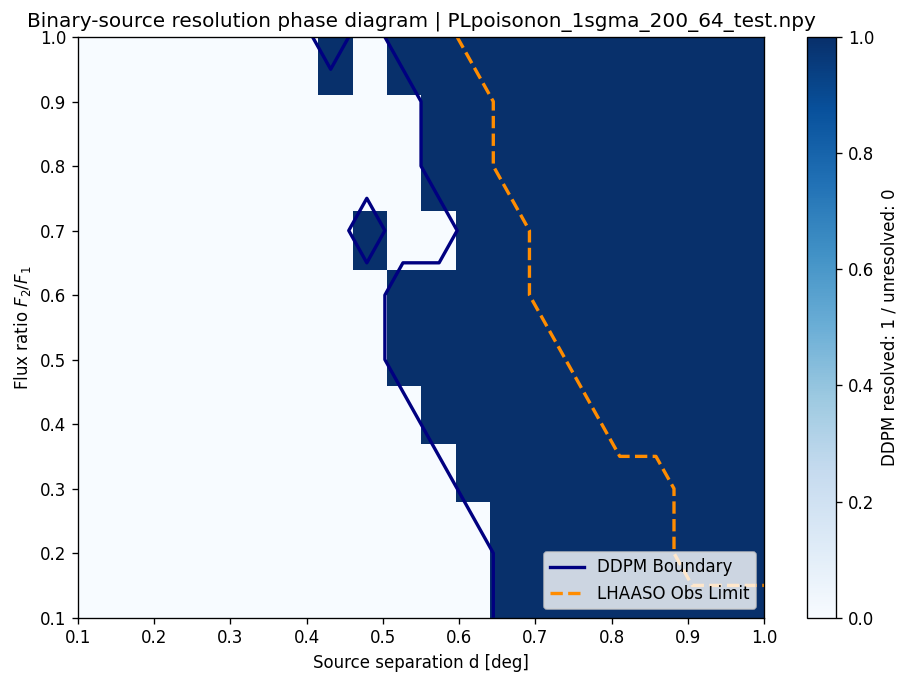


=== Binary Gaussian source size ===
Dataset sigma kind       : 1sgma
Intrinsic Gaussian sigma : 0.100 deg = 1.00 pixels
Gaussian FWHM            : 0.235 deg = 2.35 pixels
Both binary components use this same intrinsic Gaussian size; only d and F2/F1 vary.


In [7]:
def intrinsic_sigma_from_name(sigma_kind):
    if sigma_kind == "1sgma":
        return 0.1
    if sigma_kind == "3sgma":
        return 0.3
    raise ValueError(f"Cannot infer intrinsic sigma from {sigma_kind!r}")


def print_gaussian_size_info():
    sigma_deg = intrinsic_sigma_from_name(SIGMA_KIND)
    fwhm_deg = 2.354820045 * sigma_deg
    sigma_pix = sigma_deg / PIXEL_SIZE_DEG
    fwhm_pix = fwhm_deg / PIXEL_SIZE_DEG
    print("\n=== Binary Gaussian source size ===")
    print(f"Dataset sigma kind       : {SIGMA_KIND}")
    print(f"Intrinsic Gaussian sigma : {sigma_deg:.3f} deg = {sigma_pix:.2f} pixels")
    print(f"Gaussian FWHM            : {fwhm_deg:.3f} deg = {fwhm_pix:.2f} pixels")
    print("Both binary components use this same intrinsic Gaussian size; only d and F2/F1 vary.")
    return sigma_deg, fwhm_deg, sigma_pix, fwhm_pix


def plot_phase_diagram():
    fig, ax = plt.subplots(figsize=(8, 5.8))
    extent = [SEPARATIONS_DEG.min(), SEPARATIONS_DEG.max(), FLUX_RATIOS.min(), FLUX_RATIOS.max()]
    im = ax.imshow(ddpm_resolved, origin="lower", extent=extent, aspect="auto", cmap="Blues", vmin=0, vmax=1, interpolation="nearest")
    ax.contour(SEPARATIONS_DEG, FLUX_RATIOS, ddpm_resolved, levels=[0.5], colors="navy", linewidths=2, linestyles="-")
    ax.contour(SEPARATIONS_DEG, FLUX_RATIOS, lr_resolved, levels=[0.5], colors="darkorange", linewidths=2, linestyles="--")
    ax.set_xlabel("Source separation d [deg]")
    ax.set_ylabel(r"Flux ratio $F_2/F_1$")
    ax.set_title(f"Binary-source resolution phase diagram | {DATA_NAME}")
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("DDPM resolved: 1 / unresolved: 0")
    from matplotlib.lines import Line2D
    handles = [Line2D([0], [0], color="navy", lw=2, label="DDPM Boundary"), Line2D([0], [0], color="darkorange", lw=2, ls="--", label="LHAASO Obs Limit")]
    ax.legend(handles=handles, loc="lower right")
    fig.tight_layout()
    if SAVE_OUTPUTS:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        fig_path = OUTPUT_DIR / f"physical_limit_phase__{Path(DATA_NAME).stem}__{Path(MODEL_WEIGHT_NAME).stem}.png"
        fig.savefig(fig_path, dpi=300, bbox_inches="tight")
        print(f"Saved phase diagram: {fig_path}")
    plt.show()


plot_phase_diagram()
source_sigma_deg, source_fwhm_deg, source_sigma_pix, source_fwhm_pix = print_gaussian_size_info()


Representative cases selected:
  index= 12, d=0.668 deg, F2/F1=0.10, LR resolved=False, LR dip=20532727242.516, DDPM resolved=True, DDPM dip=964355111123.131
  index= 32, d=0.668 deg, F2/F1=0.20, LR resolved=False, LR dip=0.000, DDPM resolved=True, DDPM dip=842306852341.698
  index= 73, d=0.716 deg, F2/F1=0.40, LR resolved=False, LR dip=0.000, DDPM resolved=True, DDPM dip=814859628678.368
  index= 52, d=0.668 deg, F2/F1=0.30, LR resolved=False, LR dip=0.000, DDPM resolved=True, DDPM dip=779980242253.350
  index= 72, d=0.668 deg, F2/F1=0.40, LR resolved=False, LR dip=0.000, DDPM resolved=True, DDPM dip=775184452534.722
  index= 53, d=0.716 deg, F2/F1=0.30, LR resolved=False, LR dip=119750320912.407, DDPM resolved=True, DDPM dip=855877161027.001
Saved 2D figure: /root/LHAI_novel/saves/EVAL/DDPM/PhysicalLimit/physical_limit_case2d__12__PLpoisonon_1sgma_200_64_test__Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.png


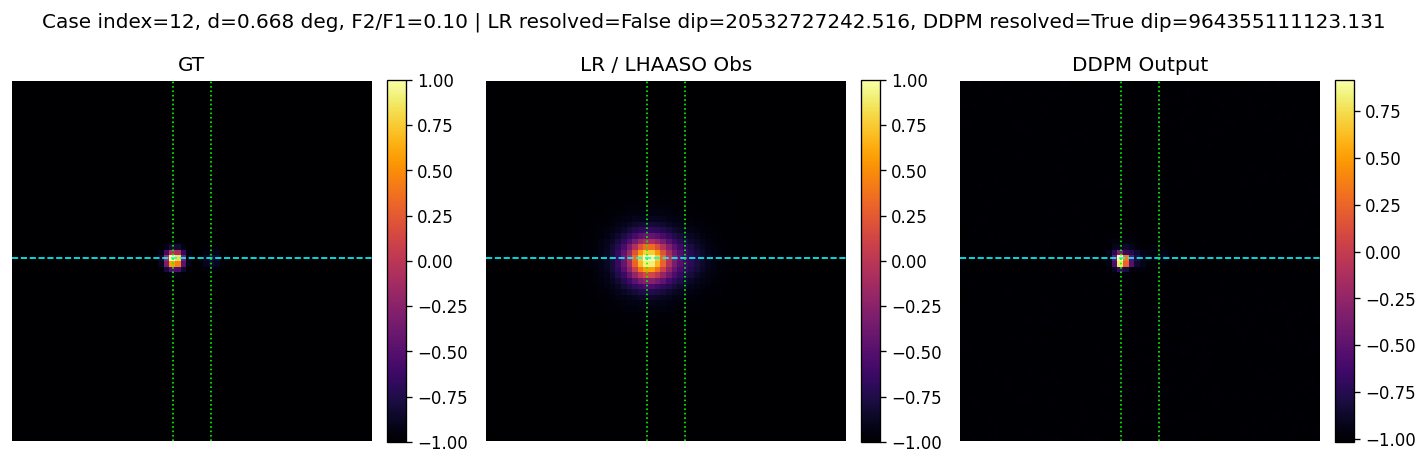

Saved 1D figure: /root/LHAI_novel/saves/EVAL/DDPM/PhysicalLimit/physical_limit_case1d__12__PLpoisonon_1sgma_200_64_test__Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.png


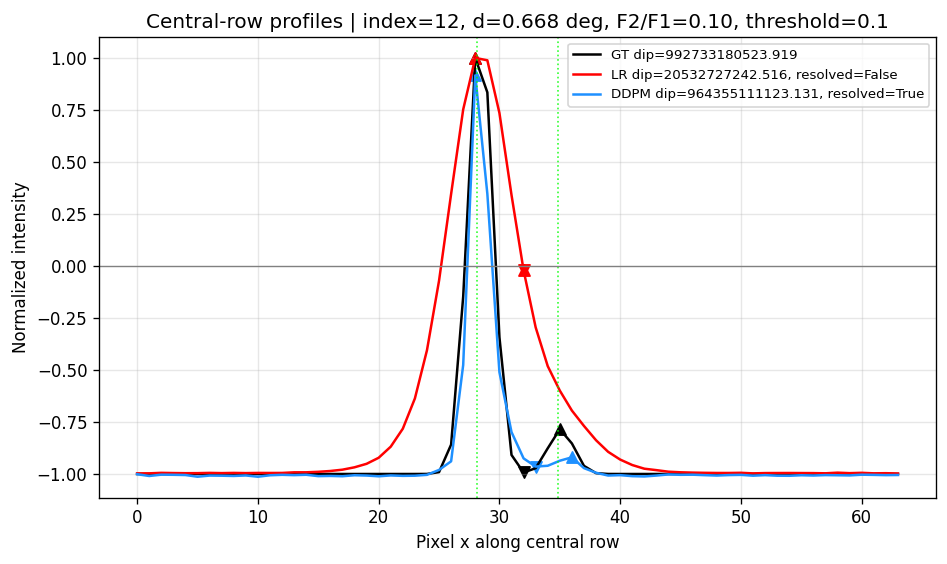

Saved 2D figure: /root/LHAI_novel/saves/EVAL/DDPM/PhysicalLimit/physical_limit_case2d__32__PLpoisonon_1sgma_200_64_test__Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.png


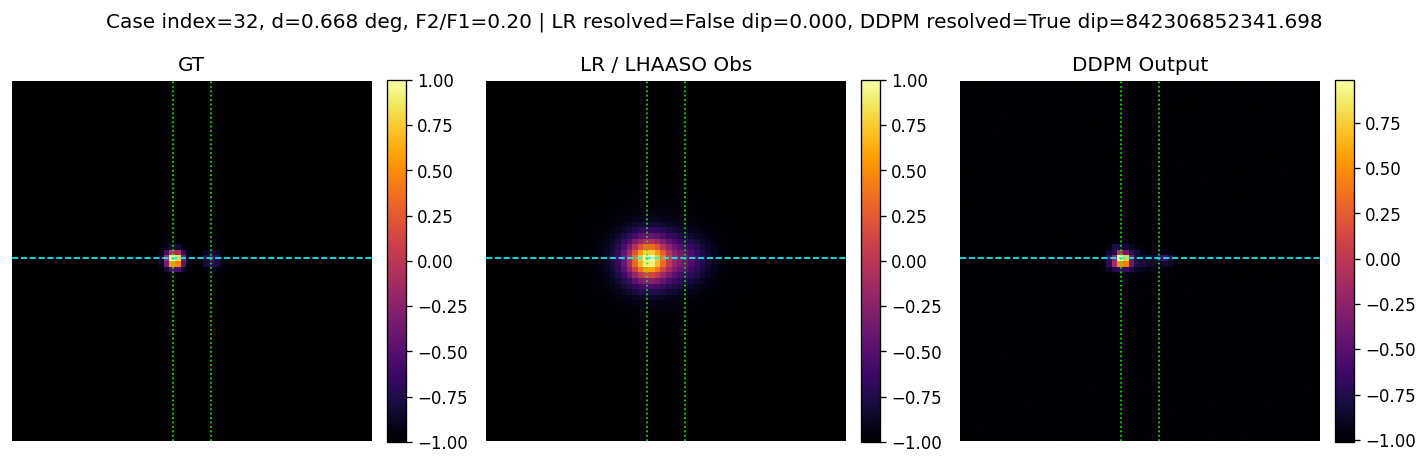

Saved 1D figure: /root/LHAI_novel/saves/EVAL/DDPM/PhysicalLimit/physical_limit_case1d__32__PLpoisonon_1sgma_200_64_test__Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.png


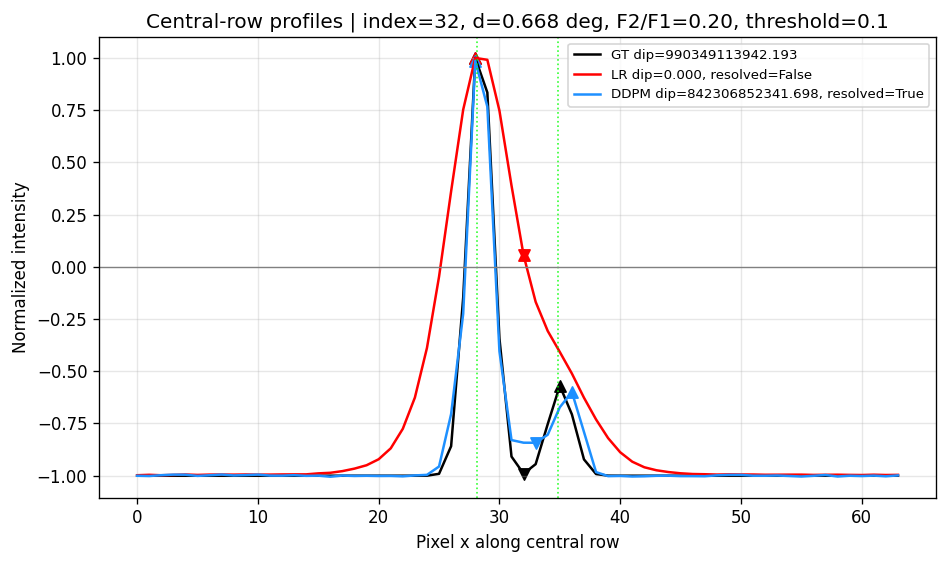

Saved 2D figure: /root/LHAI_novel/saves/EVAL/DDPM/PhysicalLimit/physical_limit_case2d__73__PLpoisonon_1sgma_200_64_test__Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.png


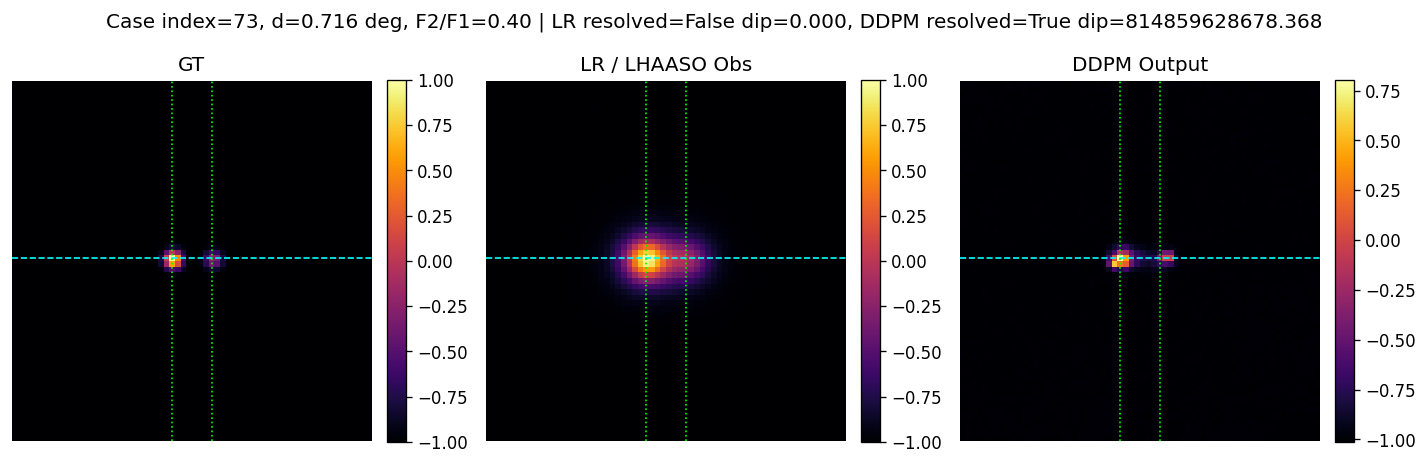

Saved 1D figure: /root/LHAI_novel/saves/EVAL/DDPM/PhysicalLimit/physical_limit_case1d__73__PLpoisonon_1sgma_200_64_test__Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.png


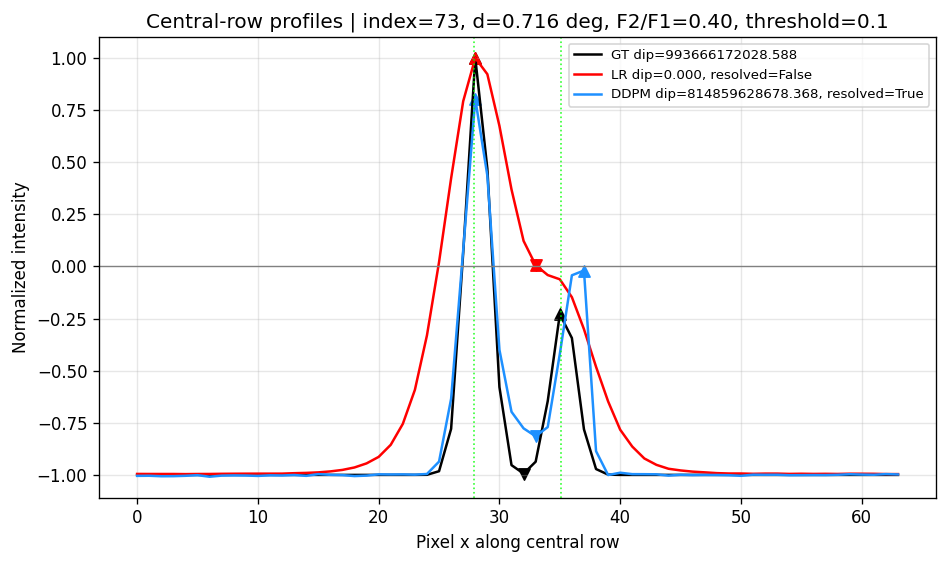

Saved 2D figure: /root/LHAI_novel/saves/EVAL/DDPM/PhysicalLimit/physical_limit_case2d__52__PLpoisonon_1sgma_200_64_test__Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.png


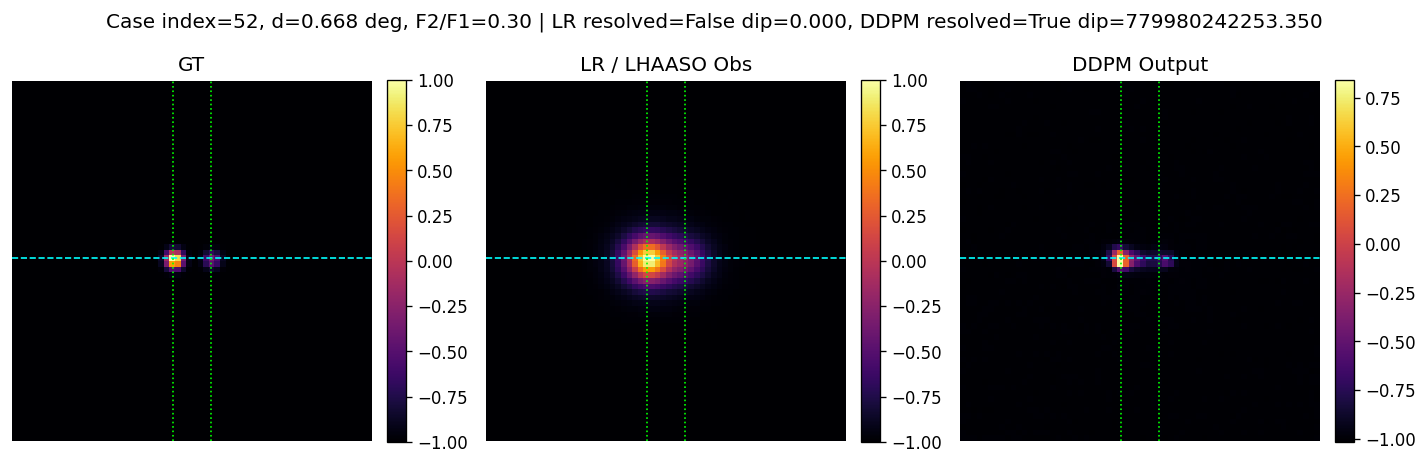

Saved 1D figure: /root/LHAI_novel/saves/EVAL/DDPM/PhysicalLimit/physical_limit_case1d__52__PLpoisonon_1sgma_200_64_test__Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.png


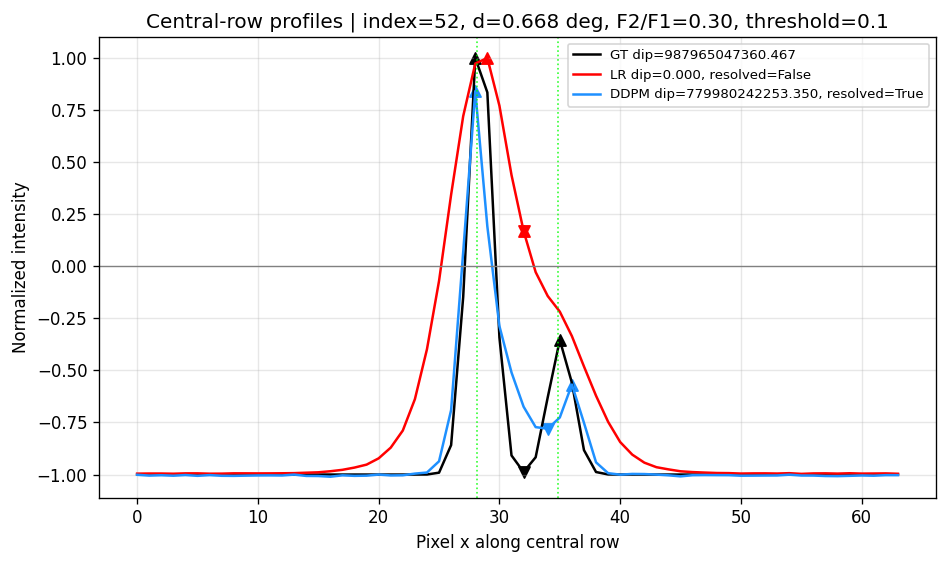

Saved 2D figure: /root/LHAI_novel/saves/EVAL/DDPM/PhysicalLimit/physical_limit_case2d__72__PLpoisonon_1sgma_200_64_test__Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.png


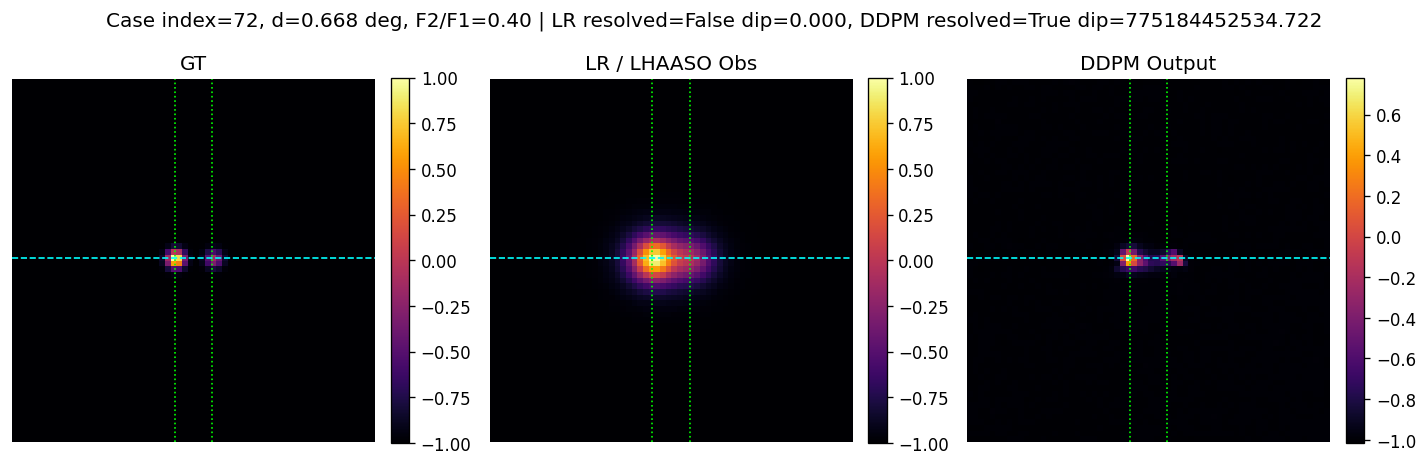

Saved 1D figure: /root/LHAI_novel/saves/EVAL/DDPM/PhysicalLimit/physical_limit_case1d__72__PLpoisonon_1sgma_200_64_test__Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.png


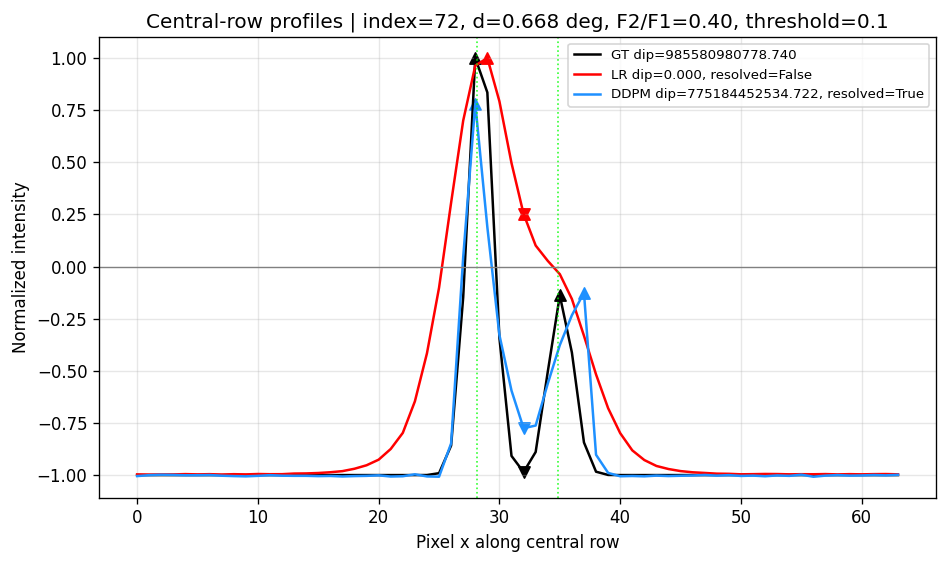

Saved 2D figure: /root/LHAI_novel/saves/EVAL/DDPM/PhysicalLimit/physical_limit_case2d__53__PLpoisonon_1sgma_200_64_test__Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.png


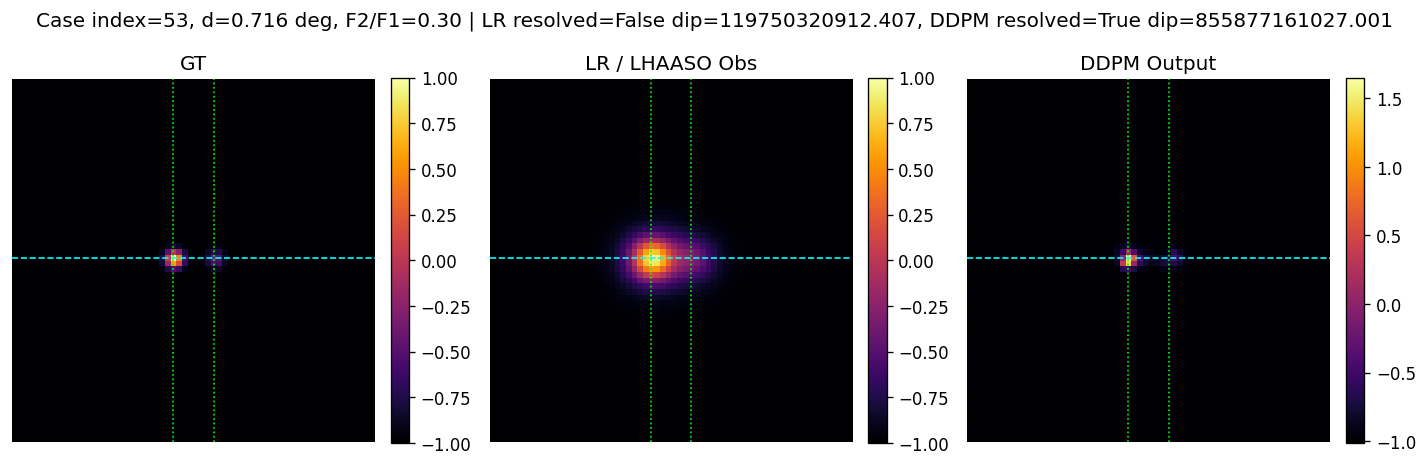

Saved 1D figure: /root/LHAI_novel/saves/EVAL/DDPM/PhysicalLimit/physical_limit_case1d__53__PLpoisonon_1sgma_200_64_test__Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.png


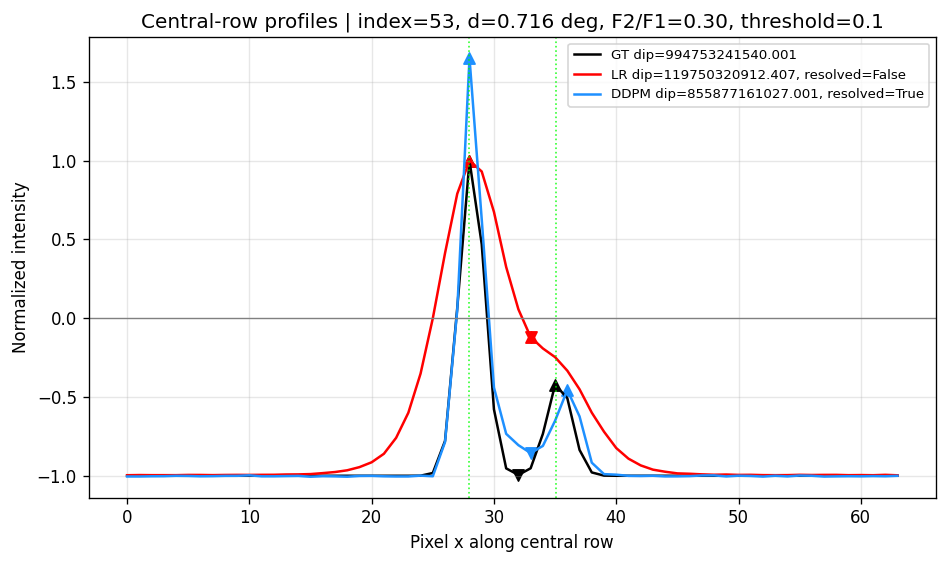

In [8]:
def select_representative_indices(count=REPRESENTATIVE_COUNT, mode=REPRESENTATIVE_SELECTION):
    if mode == "lr_unresolved_ddpm_resolved":
        candidates = np.where((lr_resolved.ravel() == 0) & (ddpm_resolved.ravel() == 1))[0]
        if len(candidates) > 0:
            scores = []
            for idx in candidates:
                d, f, d_idx, f_idx = index_to_params(int(idx))
                scores.append((ddpm_dip[f_idx, d_idx] - lr_dip[f_idx, d_idx], idx))
            return [int(idx) for _, idx in sorted(scores, reverse=True)[:count]]
    if mode == "manual":
        return [int(REPRESENTATIVE_INDEX)]
    candidates = np.arange(len(gt_model_np))
    return [int(i) for i in candidates[:count]]


def plot_case_2d(idx, prefix="physical_limit_case2d"):
    d, f, _, _ = index_to_params(idx)
    gt_img = gt_model_np[idx]
    lr_img = lr_model_np[idx]
    ddpm_img = ddpm_np[idx]
    lr_result = calculate_dip_ratio(lr_img, d_deg=d)
    ddpm_result = calculate_dip_ratio(ddpm_img, d_deg=d)
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, img, title in zip(axes, [gt_img, lr_img, ddpm_img], ["GT", "LR / LHAASO Obs", "DDPM Output"]):
        im = ax.imshow(img, origin="lower", cmap="inferno", interpolation="nearest")
        ax.axhline(SOURCE_CENTER_Y_PIX, color="cyan", ls="--", lw=1)
        for xpos in prior_peak_positions_from_d(d):
            ax.axvline(xpos, color="lime", ls=":", lw=1)
        ax.set_title(title)
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(
        f"Case index={idx}, d={d:.3f} deg, F2/F1={f:.2f} | "
        f"LR resolved={lr_result['resolved']} dip={lr_result['dip_ratio']:.3f}, "
        f"DDPM resolved={ddpm_result['resolved']} dip={ddpm_result['dip_ratio']:.3f}"
    )
    fig.tight_layout()
    if SAVE_OUTPUTS:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        fig_path = OUTPUT_DIR / f"{prefix}__{idx}__{Path(DATA_NAME).stem}__{Path(MODEL_WEIGHT_NAME).stem}.png"
        fig.savefig(fig_path, dpi=300, bbox_inches="tight")
        print(f"Saved 2D figure: {fig_path}")
    plt.show()


def plot_case_1d(idx, prefix="physical_limit_case1d"):
    d, f, _, _ = index_to_params(idx)
    gt_img = gt_model_np[idx]
    lr_img = lr_model_np[idx]
    ddpm_img = ddpm_np[idx]
    gt_result = calculate_dip_ratio(gt_img, d_deg=d)
    lr_result = calculate_dip_ratio(lr_img, d_deg=d)
    ddpm_result = calculate_dip_ratio(ddpm_img, d_deg=d)
    fig, ax = plt.subplots(figsize=(8, 4.8))
    x = np.arange(gt_img.shape[1])
    for profile, label, result, color in [
        (gt_result["profile"], f"GT dip={gt_result['dip_ratio']:.3f}", gt_result, "black"),
        (lr_result["profile"], f"LR dip={lr_result['dip_ratio']:.3f}, resolved={lr_result['resolved']}", lr_result, "red"),
        (ddpm_result["profile"], f"DDPM dip={ddpm_result['dip_ratio']:.3f}, resolved={ddpm_result['resolved']}", ddpm_result, "dodgerblue"),
    ]:
        ax.plot(x, profile, label=label, color=color)
        for key, marker in [("p1_idx", "^"), ("p2_idx", "^"), ("saddle_idx", "v")]:
            pos = result[key]
            if pos is not None:
                ax.scatter([pos], [profile[pos]], color=color, marker=marker, s=45)
    for xpos in prior_peak_positions_from_d(d):
        ax.axvline(xpos, color="lime", ls=":", lw=1, alpha=0.8)
    ax.axhline(0, color="gray", lw=0.8)
    ax.set_xlabel("Pixel x along central row")
    ax.set_ylabel("Normalized intensity")
    ax.set_title(f"Central-row profiles | index={idx}, d={d:.3f} deg, F2/F1={f:.2f}, threshold={DIP_THRESHOLD}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    if SAVE_OUTPUTS:
        fig_path = OUTPUT_DIR / f"{prefix}__{idx}__{Path(DATA_NAME).stem}__{Path(MODEL_WEIGHT_NAME).stem}.png"
        fig.savefig(fig_path, dpi=300, bbox_inches="tight")
        print(f"Saved 1D figure: {fig_path}")
    plt.show()


representative_indices = select_representative_indices()
if not representative_indices:
    representative_indices = [int(REPRESENTATIVE_INDEX)]
print("Representative cases selected:")
for idx in representative_indices:
    d, f, d_idx, f_idx = index_to_params(idx)
    print(
        f"  index={idx:3d}, d={d:.3f} deg, F2/F1={f:.2f}, "
        f"LR resolved={bool(lr_resolved[f_idx, d_idx])}, LR dip={lr_dip[f_idx, d_idx]:.3f}, "
        f"DDPM resolved={bool(ddpm_resolved[f_idx, d_idx])}, DDPM dip={ddpm_dip[f_idx, d_idx]:.3f}"
    )

for idx in representative_indices:
    plot_case_2d(idx)
    plot_case_1d(idx)



=== LR failed (144 cases) ===
index=  0, d=0.100 deg, F2/F1=0.10, LR resolved=False, LR dip=0.000, DDPM resolved=False, DDPM dip=0.000
index=  1, d=0.147 deg, F2/F1=0.10, LR resolved=False, LR dip=0.000, DDPM resolved=False, DDPM dip=0.000
index=  2, d=0.195 deg, F2/F1=0.10, LR resolved=False, LR dip=0.000, DDPM resolved=False, DDPM dip=0.000
index=  3, d=0.242 deg, F2/F1=0.10, LR resolved=False, LR dip=0.000, DDPM resolved=False, DDPM dip=0.000
index=  4, d=0.289 deg, F2/F1=0.10, LR resolved=False, LR dip=0.000, DDPM resolved=False, DDPM dip=0.000
index=  5, d=0.337 deg, F2/F1=0.10, LR resolved=False, LR dip=0.000, DDPM resolved=False, DDPM dip=0.000
index=  6, d=0.384 deg, F2/F1=0.10, LR resolved=False, LR dip=0.000, DDPM resolved=False, DDPM dip=231826245785.760
index=  7, d=0.432 deg, F2/F1=0.10, LR resolved=False, LR dip=0.000, DDPM resolved=False, DDPM dip=0.000
index=  8, d=0.479 deg, F2/F1=0.10, LR resolved=False, LR dip=0.000, DDPM resolved=False, DDPM dip=0.000
index=  9, d=

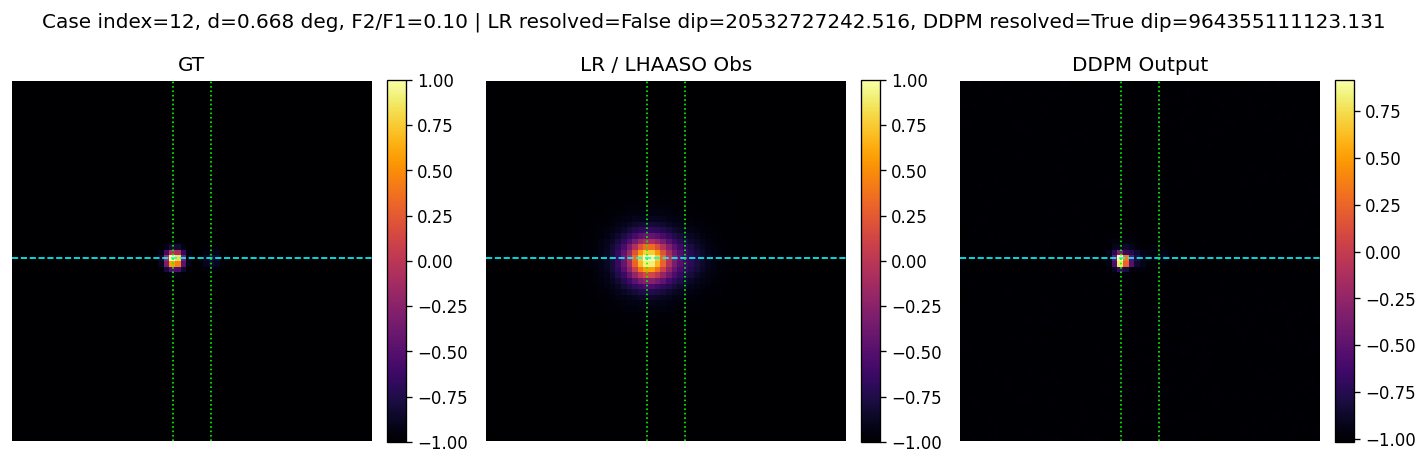

Saved 1D figure: /root/LHAI_novel/saves/EVAL/DDPM/PhysicalLimit/physical_limit_failure_lr_failed_ddpm_resolved_1d__12__PLpoisonon_1sgma_200_64_test__Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.png


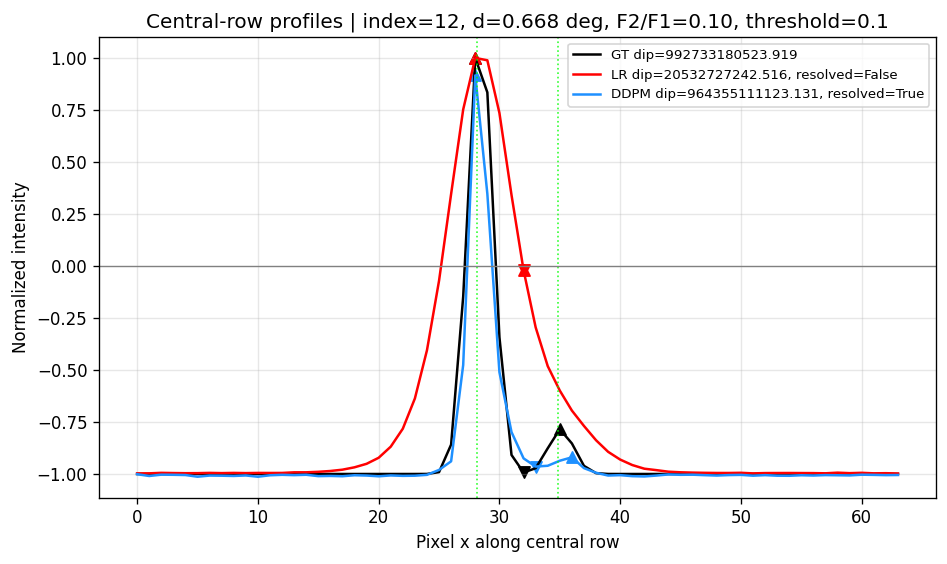

Saved 2D figure: /root/LHAI_novel/saves/EVAL/DDPM/PhysicalLimit/physical_limit_failure_lr_failed_ddpm_resolved_2d__32__PLpoisonon_1sgma_200_64_test__Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.png


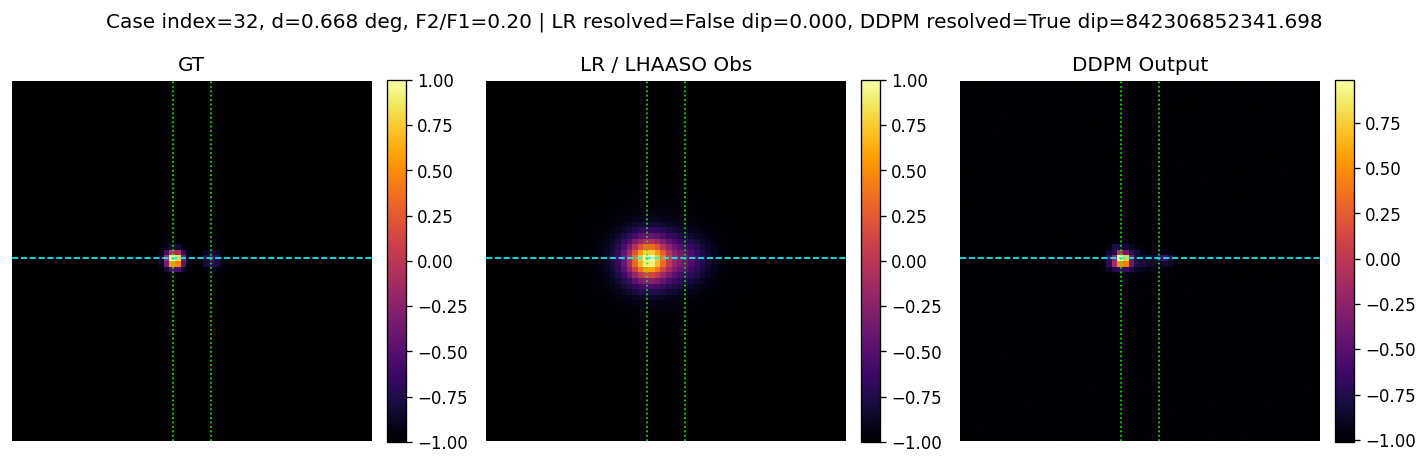

Saved 1D figure: /root/LHAI_novel/saves/EVAL/DDPM/PhysicalLimit/physical_limit_failure_lr_failed_ddpm_resolved_1d__32__PLpoisonon_1sgma_200_64_test__Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.png


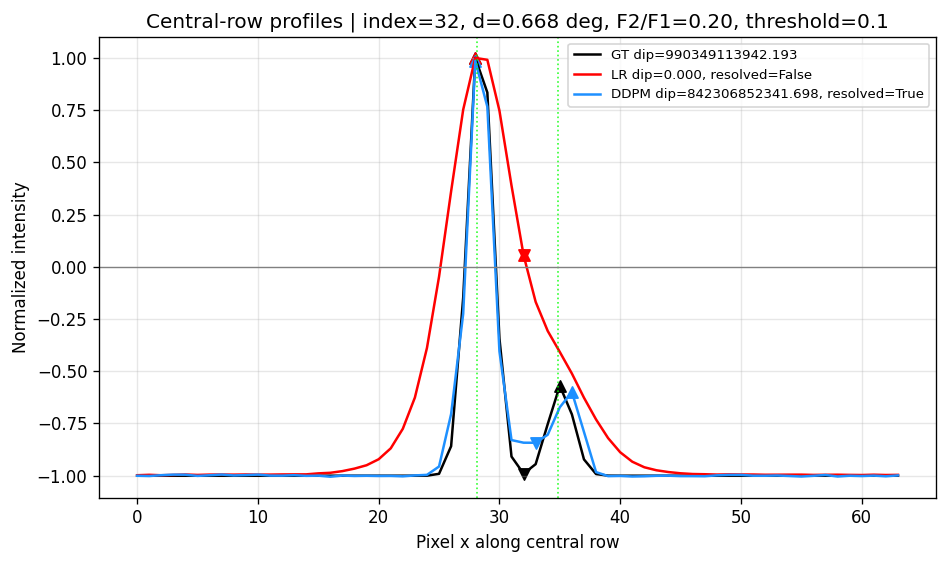

Saved 2D figure: /root/LHAI_novel/saves/EVAL/DDPM/PhysicalLimit/physical_limit_failure_lr_failed_ddpm_resolved_2d__73__PLpoisonon_1sgma_200_64_test__Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.png


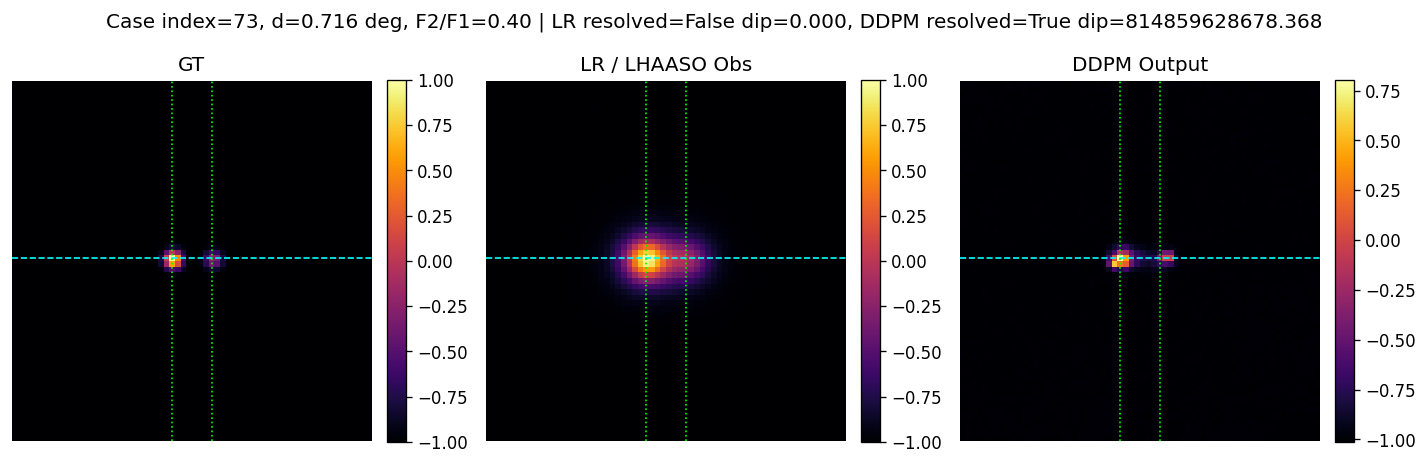

Saved 1D figure: /root/LHAI_novel/saves/EVAL/DDPM/PhysicalLimit/physical_limit_failure_lr_failed_ddpm_resolved_1d__73__PLpoisonon_1sgma_200_64_test__Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.png


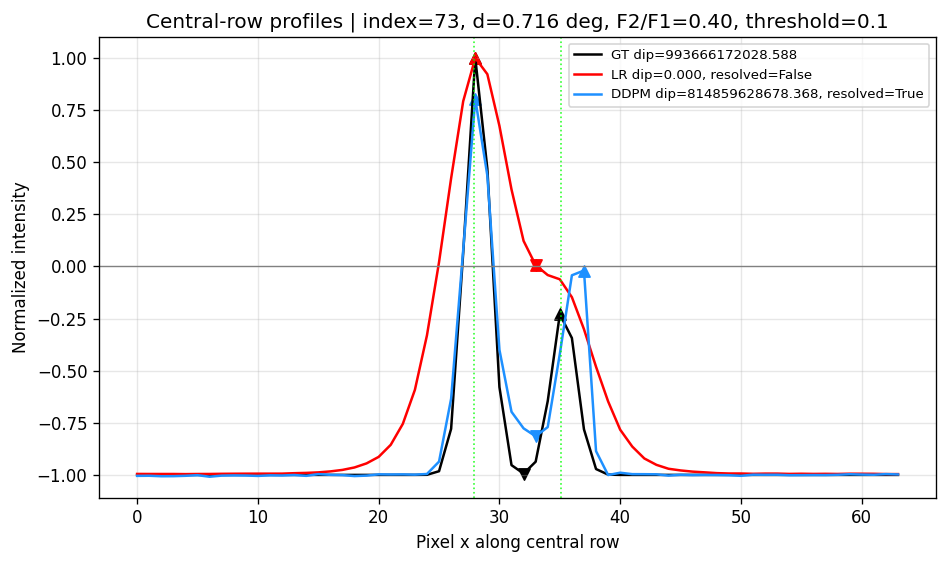

Saved 2D figure: /root/LHAI_novel/saves/EVAL/DDPM/PhysicalLimit/physical_limit_failure_lr_failed_ddpm_resolved_2d__52__PLpoisonon_1sgma_200_64_test__Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.png


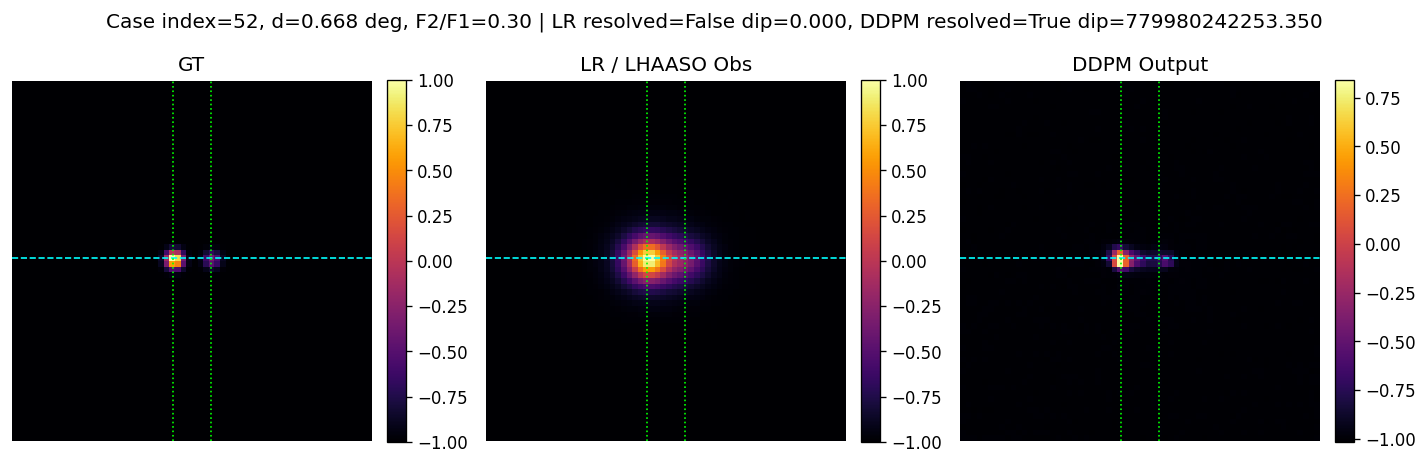

Saved 1D figure: /root/LHAI_novel/saves/EVAL/DDPM/PhysicalLimit/physical_limit_failure_lr_failed_ddpm_resolved_1d__52__PLpoisonon_1sgma_200_64_test__Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.png


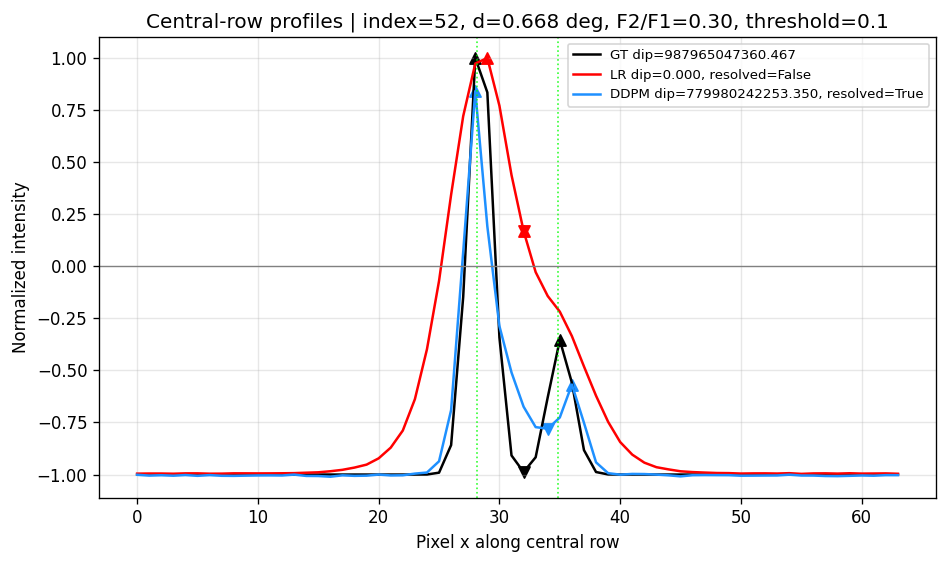


No cases to visualize for lr_resolved_ddpm_failed.

Visualizing both_failed: [188, 168, 148, 108]
Saved 2D figure: /root/LHAI_novel/saves/EVAL/DDPM/PhysicalLimit/physical_limit_failure_both_failed_2d__188__PLpoisonon_1sgma_200_64_test__Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.png


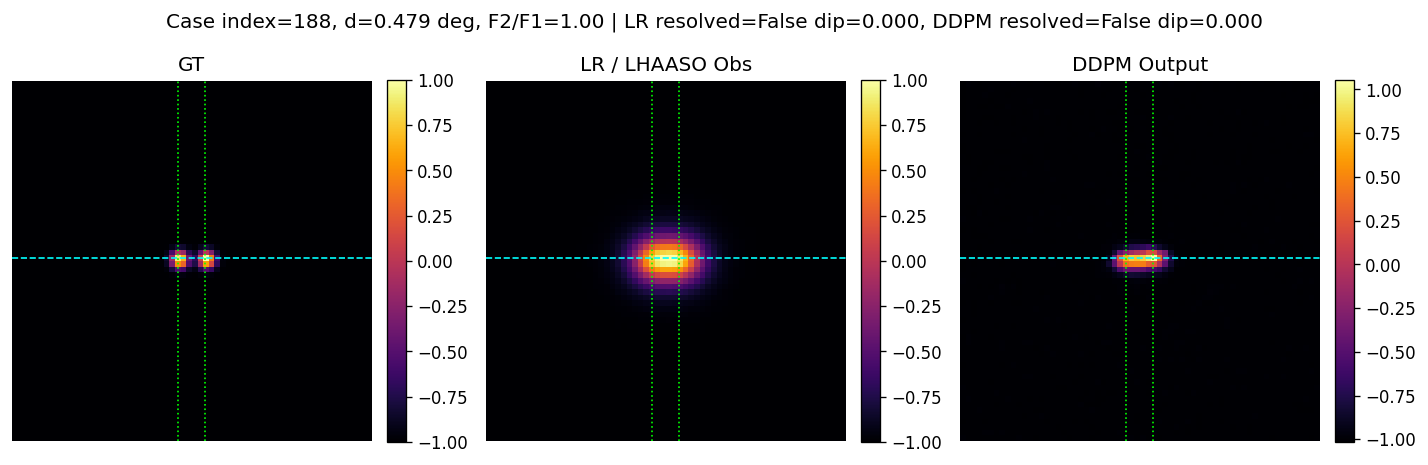

Saved 1D figure: /root/LHAI_novel/saves/EVAL/DDPM/PhysicalLimit/physical_limit_failure_both_failed_1d__188__PLpoisonon_1sgma_200_64_test__Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.png


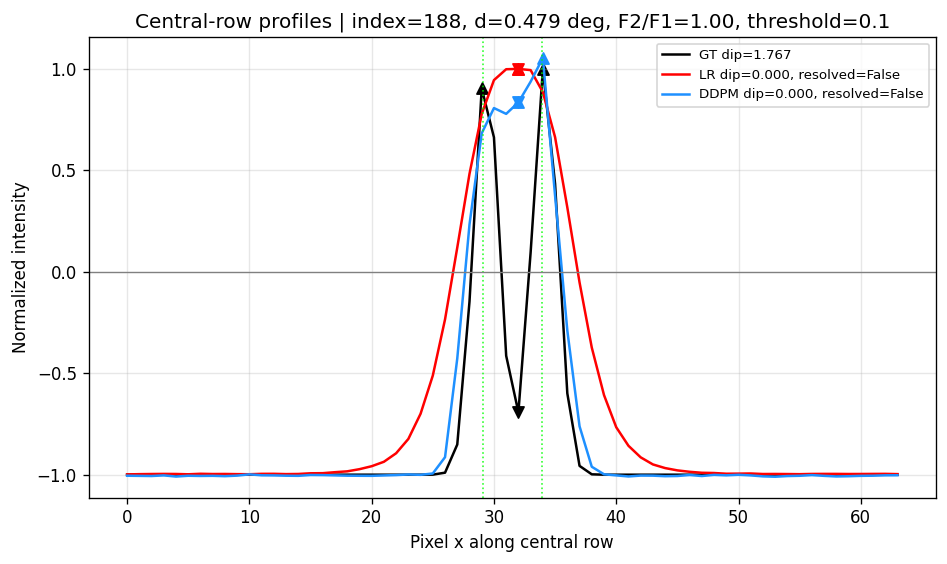

Saved 2D figure: /root/LHAI_novel/saves/EVAL/DDPM/PhysicalLimit/physical_limit_failure_both_failed_2d__168__PLpoisonon_1sgma_200_64_test__Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.png


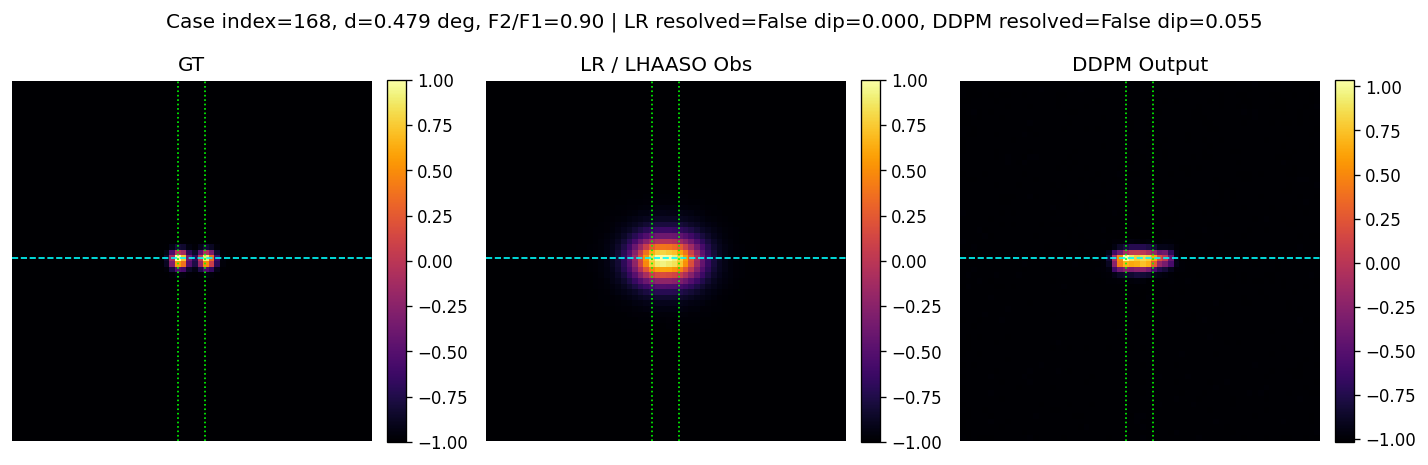

Saved 1D figure: /root/LHAI_novel/saves/EVAL/DDPM/PhysicalLimit/physical_limit_failure_both_failed_1d__168__PLpoisonon_1sgma_200_64_test__Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.png


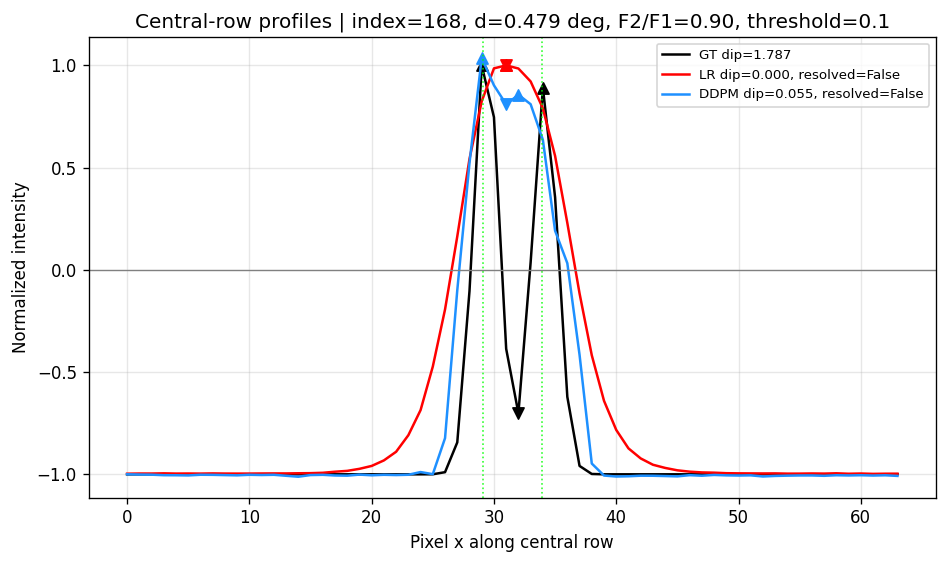

Saved 2D figure: /root/LHAI_novel/saves/EVAL/DDPM/PhysicalLimit/physical_limit_failure_both_failed_2d__148__PLpoisonon_1sgma_200_64_test__Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.png


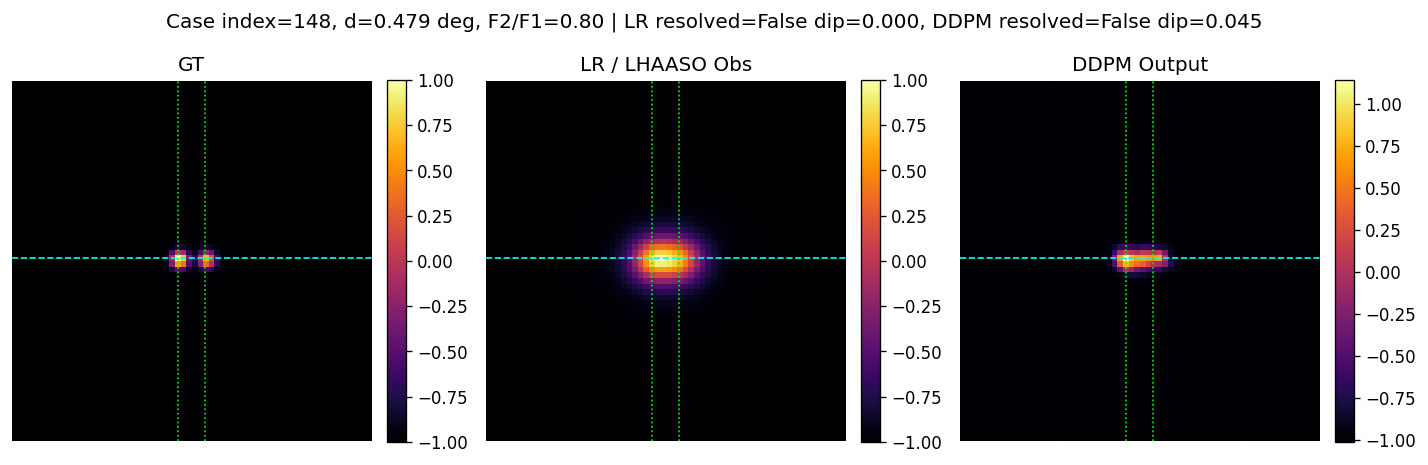

Saved 1D figure: /root/LHAI_novel/saves/EVAL/DDPM/PhysicalLimit/physical_limit_failure_both_failed_1d__148__PLpoisonon_1sgma_200_64_test__Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.png


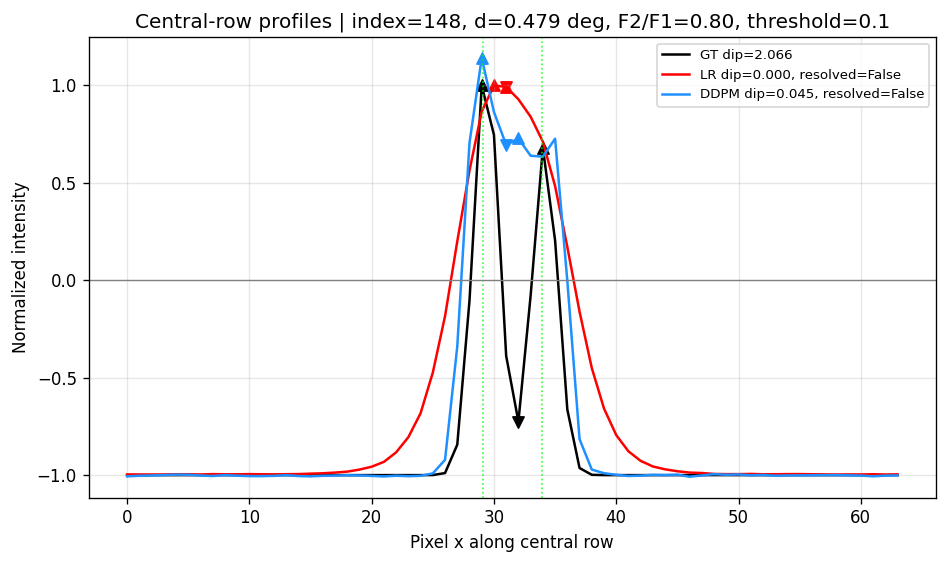

Saved 2D figure: /root/LHAI_novel/saves/EVAL/DDPM/PhysicalLimit/physical_limit_failure_both_failed_2d__108__PLpoisonon_1sgma_200_64_test__Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.png


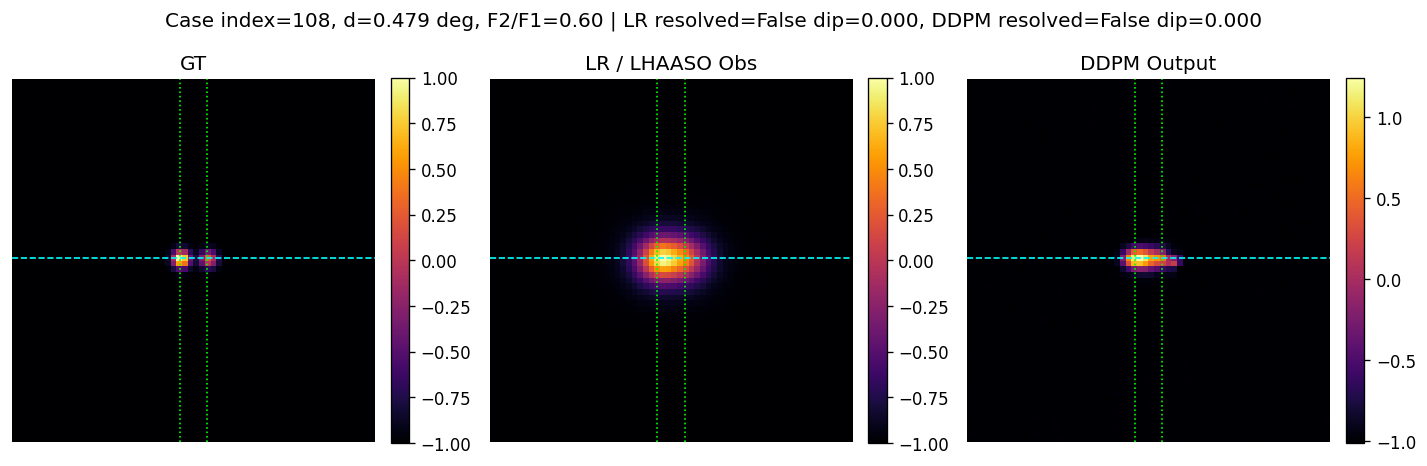

Saved 1D figure: /root/LHAI_novel/saves/EVAL/DDPM/PhysicalLimit/physical_limit_failure_both_failed_1d__108__PLpoisonon_1sgma_200_64_test__Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.png


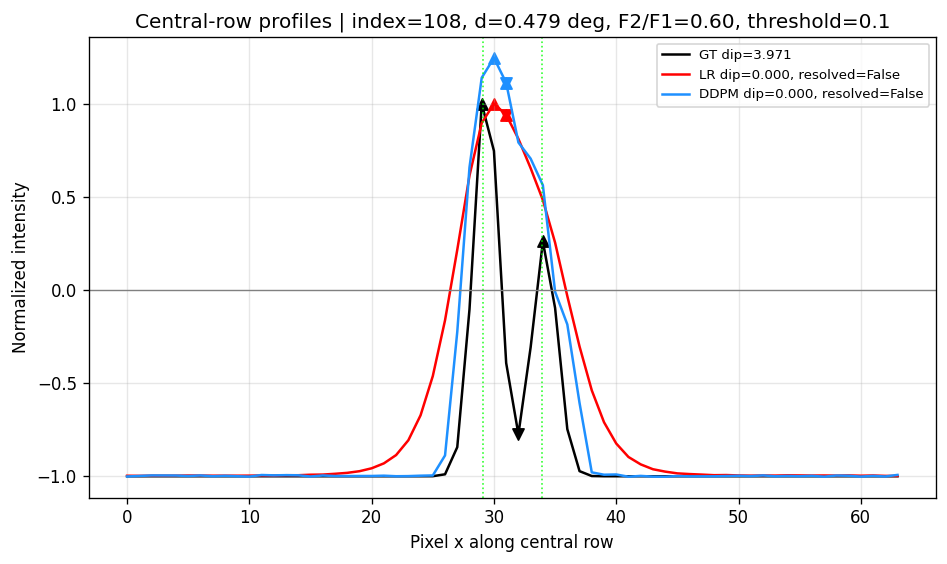


Set MANUAL_CASE_INDICES = [idx1, idx2, ...] in the config cell to visualize chosen cases manually.


In [9]:
def describe_indices(title, indices):
    print(f"\n=== {title} ({len(indices)} cases) ===")
    for idx in indices:
        d, f, d_idx, f_idx = index_to_params(int(idx))
        print(
            f"index={int(idx):3d}, d={d:.3f} deg, F2/F1={f:.2f}, "
            f"LR resolved={bool(lr_resolved[f_idx, d_idx])}, LR dip={lr_dip[f_idx, d_idx]:.3f}, "
            f"DDPM resolved={bool(ddpm_resolved[f_idx, d_idx])}, DDPM dip={ddpm_dip[f_idx, d_idx]:.3f}"
        )


lr_failed_indices = np.where(lr_resolved.ravel() == 0)[0].astype(int).tolist()
ddpm_failed_indices = np.where(ddpm_resolved.ravel() == 0)[0].astype(int).tolist()
lr_failed_ddpm_resolved_indices = np.where((lr_resolved.ravel() == 0) & (ddpm_resolved.ravel() == 1))[0].astype(int).tolist()
lr_resolved_ddpm_failed_indices = np.where((lr_resolved.ravel() == 1) & (ddpm_resolved.ravel() == 0))[0].astype(int).tolist()
both_failed_indices = np.where((lr_resolved.ravel() == 0) & (ddpm_resolved.ravel() == 0))[0].astype(int).tolist()

describe_indices("LR failed", lr_failed_indices)
describe_indices("DDPM failed", ddpm_failed_indices)
describe_indices("LR failed but DDPM resolved", lr_failed_ddpm_resolved_indices)
describe_indices("LR resolved but DDPM failed", lr_resolved_ddpm_failed_indices)
describe_indices("Both failed", both_failed_indices)


def select_failure_examples(indices, count=FAILURE_CASE_COUNT, prefer="largest_ddpm_minus_lr"):
    if not indices:
        return []
    scored = []
    for idx in indices:
        d, f, d_idx, f_idx = index_to_params(int(idx))
        if prefer == "largest_ddpm_minus_lr":
            score = ddpm_dip[f_idx, d_idx] - lr_dip[f_idx, d_idx]
        elif prefer == "largest_lr_minus_ddpm":
            score = lr_dip[f_idx, d_idx] - ddpm_dip[f_idx, d_idx]
        else:
            score = -abs(d - 0.5)
        scored.append((score, int(idx)))
    return [idx for _, idx in sorted(scored, reverse=True)[:count]]


failure_visual_groups = {
    "lr_failed_ddpm_resolved": select_failure_examples(lr_failed_ddpm_resolved_indices, prefer="largest_ddpm_minus_lr"),
    "lr_resolved_ddpm_failed": select_failure_examples(lr_resolved_ddpm_failed_indices, prefer="largest_lr_minus_ddpm"),
    "both_failed": select_failure_examples(both_failed_indices, prefer="middle"),
}

for group_name, indices in failure_visual_groups.items():
    if not indices:
        print(f"\nNo cases to visualize for {group_name}.")
        continue
    print(f"\nVisualizing {group_name}: {indices}")
    for idx in indices:
        plot_case_2d(idx, prefix=f"physical_limit_failure_{group_name}_2d")
        plot_case_1d(idx, prefix=f"physical_limit_failure_{group_name}_1d")

if MANUAL_CASE_INDICES:
    print(f"\nManual case visualization: {MANUAL_CASE_INDICES}")
    for idx in MANUAL_CASE_INDICES:
        plot_case_2d(int(idx), prefix="physical_limit_manual_case2d")
        plot_case_1d(int(idx), prefix="physical_limit_manual_case1d")
else:
    print("\nSet MANUAL_CASE_INDICES = [idx1, idx2, ...] in the config cell to visualize chosen cases manually.")


In [10]:
if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    stem = f"{Path(DATA_NAME).stem}__{Path(MODEL_WEIGHT_NAME).stem}"
    np.save(OUTPUT_DIR / f"ddpm_outputs__{stem}.npy", ddpm_np.astype(np.float32))
    np.save(OUTPUT_DIR / f"gt_resolved__{stem}.npy", gt_resolved.astype(np.float32))
    np.save(OUTPUT_DIR / f"lr_resolved__{stem}.npy", lr_resolved.astype(np.float32))
    np.save(OUTPUT_DIR / f"ddpm_resolved__{stem}.npy", ddpm_resolved.astype(np.float32))
    np.save(OUTPUT_DIR / f"gt_dip_ratio__{stem}.npy", gt_dip.astype(np.float32))
    np.save(OUTPUT_DIR / f"lr_dip_ratio__{stem}.npy", lr_dip.astype(np.float32))
    np.save(OUTPUT_DIR / f"ddpm_dip_ratio__{stem}.npy", ddpm_dip.astype(np.float32))
    csv_path = OUTPUT_DIR / f"physical_limit_results__{stem}.csv"
    with csv_path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=["source", "index", "d_deg", "flux_ratio", "resolved", "dip_ratio"])
        writer.writeheader()
        for row in gt_rows:
            writer.writerow({"source": "GT", **row})
        for row in lr_rows:
            writer.writerow({"source": "LR", **row})
        for row in ddpm_rows:
            writer.writerow({"source": "DDPM", **row})
    meta = {
        "data_path": str(data_path),
        "model_weight_path": str(model_weight_path),
        "image_size": IMAGE_SIZE,
        "data_range": DATA_RANGE,
        "dip_threshold": DIP_THRESHOLD,
        "pixel_size_deg": PIXEL_SIZE_DEG,
        "source_center_x_pix": SOURCE_CENTER_X_PIX,
        "source_center_y_pix": SOURCE_CENTER_Y_PIX,
        "prior_peak_search_radius_pix": PRIOR_PEAK_SEARCH_RADIUS_PIX,
        "separations_deg": SEPARATIONS_DEG.tolist(),
        "flux_ratios": FLUX_RATIOS.tolist(),
        "lr_failed_indices": lr_failed_indices,
        "ddpm_failed_indices": ddpm_failed_indices,
        "lr_failed_ddpm_resolved_indices": lr_failed_ddpm_resolved_indices,
        "lr_resolved_ddpm_failed_indices": lr_resolved_ddpm_failed_indices,
        "both_failed_indices": both_failed_indices,
        "manual_case_indices": MANUAL_CASE_INDICES,
        "created_at": datetime.now().isoformat(timespec="seconds"),
    }
    (OUTPUT_DIR / f"physical_limit_metadata__{stem}.json").write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"Saved arrays, CSV, and metadata under {OUTPUT_DIR}")


Saved arrays, CSV, and metadata under /root/LHAI_novel/saves/EVAL/DDPM/PhysicalLimit
